In [14]:
#1. OBSERVAMOS LAS DIMENSIONES DE LOS DATOS
import h5py as h5
import numpy as np
import time
import pandas as pd
import os
import json
# 1. Configuración de la ruta
ruta_maestra = r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5"

ruta_carpeta_guardar= r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\runtransformer1"
# Crear la carpeta si no existe
os.makedirs(ruta_carpeta_guardar, exist_ok=True)

with h5.File(ruta_maestra, 'r') as f:
    # Leemos las dimensiones de las tres componentes
    grupo = f['data_analisis']
    u_shape = grupo['u_fluc'].shape
    v_shape = grupo['v_fluc'].shape
    w_shape = grupo['w_fluc'].shape

# Verificación de seguridad: las 3 matrices deben ser idénticas en tamaño
assert u_shape == v_shape == w_shape, "¡Error crítico! Las dimensiones de U, V y W no coinciden."

num_tiempos = u_shape[0]
dim_y = u_shape[1] #number of lines of probes
dim_z = u_shape[2]
total_puntos_espaciales = dim_y * dim_z

print("--- ESTADÍSTICAS DEL DATASET MULTICANAL ---")
print(f"Total de instantes de tiempo: {num_tiempos}")
print(f"Malla espacial: {dim_y} x {dim_z} = {total_puntos_espaciales} puntos")
print(f"Canales de velocidad: 3 (U, V, W)")
print(f"Total de datos numéricos a procesar: {num_tiempos * total_puntos_espaciales * 3:,}")

# 2. CÁLCULO DE DIVISIONES (Splits temporales)
# Primero separamos el 20% para el examen final (test/resultados)
indice_test = int(num_tiempos * 0.8)

# Del 80% restante, separamos otro 20% para validación (0.8 * 0.8 = 0.64)
indice_val = int(indice_test * 0.8)

salto = 50

print("\n--- REPARTO DEL TIEMPO ---")
print(f"1. Entrenamiento (64%): Pasos 0 al {indice_val}")
print(f"2. Validación    (16%): Pasos {indice_val} al {indice_test}")
print(f"3. Resultados    (20%): Pasos {indice_test} al {num_tiempos}")

--- ESTADÍSTICAS DEL DATASET MULTICANAL ---
Total de instantes de tiempo: 106000
Malla espacial: 7 x 288 = 2016 puntos
Canales de velocidad: 3 (U, V, W)
Total de datos numéricos a procesar: 641,088,000

--- REPARTO DEL TIEMPO ---
1. Entrenamiento (64%): Pasos 0 al 67840
2. Validación    (16%): Pasos 67840 al 84800
3. Resultados    (20%): Pasos 84800 al 106000


In [15]:
#2. PREPARACIÓN DE LOS DATOS PARA EL MODELO
import torch
from torch.utils.data import TensorDataset, DataLoader 
import os
import gc  # <--- Importamos el recolector de basura

def obtener_o_crear_datasets(ruta_maestra, train_dataset_pt_tf, val_dataset_pt_tf, stats_pt_tf, linea_idy):
    """
    Comprueba si existen los archivos procesados. 
    Si existen, los carga. Si no, ejecuta la lógica de 5760 columnas y los guarda.
    """
    
    # 1. Comprobar si AMBOS archivos ya existen en el disco
    if os.path.exists(train_dataset_pt_tf) and os.path.exists(val_dataset_pt_tf) and os.path.exists(stats_pt_tf):
        print(f"📦 Archivos detectados. Cargando datasets desde {train_dataset_pt_tf}...")
        train_ds = torch.load(train_dataset_pt_tf,weights_only=False)
        val_ds = torch.load(val_dataset_pt_tf,weights_only=False)
        stats = torch.load(stats_pt_tf, weights_only=False)
        return train_ds, val_ds, stats


    else:

        with h5.File(ruta_maestra, 'r') as f:
            # 1. Suponiendo que 'datos' es tu matriz original de forma (106000, 7, 288)
            matriz_base = f['data_analisis']['u_fluc'][:, linea_idy, :]  # Forma: (106000, 288)

            # 2. Definimos las dimensiones y el tamaño de los paquetes
            chunk_size = 16500  # Número de filas por paquete (chunk)
            num_chunks = len(matriz_base) // chunk_size  # 106000 // 5050 = 20

            # Recortamos la matriz para que el tamaño sea múltiplo exacto
            matriz_recortada = matriz_base[:num_chunks * chunk_size, :]

            # 3. Transformación de las dimensiones
           
            trozos = []
            for i in range(num_chunks):
                inicio = i * chunk_size
                fin = (i + 1) * chunk_size
                pedazo = matriz_recortada[inicio:fin, :]
                trozos.append(pedazo)

            # 3. Los "pegamos" de lado (horizontalmente)
            # matriz_final pasará a ser (5050, 288 * 20) = (5050, 5760)
            matriz_final_raw = np.hstack(trozos)

            print("Forma de la matriz final:", matriz_final_raw.shape) # Imprimirá (5050, 5760)

        # 5. DIVISIÓN 80/20 DE LAS COLUMNAS (5760)
        # ==========================================
        total_columnas = matriz_final_raw.shape[1] # 5760
        split_idx = int(total_columnas * 0.8) # 4608

        # 1. Creamos una lista de índices y la barajamos aleatoriamente
        # Usamos una semilla (seed) para que la aleatoriedad sea igual siempre que ejecutes el código
        np.random.seed(42) 
        indices_barajados = np.random.permutation(total_columnas)


        # 2. Separamos esos índices en los grupos de entrenamiento y validación
        train_indices = indices_barajados[:split_idx] # Los primeros 4608 números aleatorios
        val_indices = indices_barajados[split_idx:]   # Los 1152 restantes

        # Extraemos TODA la serie temporal (5050 pasos) pero separada por puntos espaciales
        matriz_train_raw = matriz_final_raw[:, train_indices] # Forma: (5050, 4608)
        matriz_val_raw = matriz_final_raw[:, val_indices]     # Forma: (5050, 1152)


                
        #Normalizamos los datos usando la media y desviación de X_data_raw (¡MUY IMPORTANTE!)
        media_X = np.mean(matriz_train_raw)
        std_X = np.std(matriz_train_raw)

        #Guardamos las estadísticas para usarlas en la normalización de los datos de validación y test
        stats = {
            'media': media_X,
            'std': std_X
        }

        matriz_train = np.float32((matriz_train_raw - media_X) / std_X)
        matriz_val = np.float32((matriz_val_raw - media_X) / std_X)

        # TRUCO 2: Borramos las variables gigantes que ya no usamos y vaciamos RAM
        del matriz_final_raw, matriz_train_raw, matriz_val_raw, trozos, matriz_recortada
        gc.collect()

        # ==========================================
        # 6. CREACIÓN DE VENTANAS DESLIZANTES
        # ==========================================
        seq_x = 500  # Historia pasada (Input Transformer)
        seq_y = 50   # Futuro a predecir (Output Transformer)
        salto = 50   # Cuántos pasos temporales saltamos por ventana (ahorra RAM)

        def crear_ventanas(matriz, lookback, predict, stride):
            X_lista, y_lista = [], []
            num_tiempos = matriz.shape[0]
            
            # Deslizamos la ventana por el eje del tiempo
            for i in range(0, num_tiempos - lookback - predict + 1, stride):
                # Extraemos los bloques de tiempo
                bloque_x = matriz[i : i + lookback, :]       # Forma: (500, columnas)
                bloque_y = matriz[i + lookback : i + lookback + predict, :] # Forma: (50, columnas)
                
                # Transponemos (.T) para que las columnas (puntos espaciales) sean los ejemplos (filas)
                # Al transponer: bloque_x pasa de (500, col) a (col, 500)
                X_lista.append(bloque_x.T)
                y_lista.append(bloque_y.T)
            
            # Apilamos verticalmente todos los fragmentos generados
            return np.vstack(X_lista), np.vstack(y_lista)
        


        print("\nGenerando ventanas deslizantes (esto puede tardar unos segundos)...")
        X_train_np_tf, y_train_np_tf = crear_ventanas(matriz_train, seq_x, seq_y, salto)
        X_val_np_tf, y_val_np_tf = crear_ventanas(matriz_val, seq_x, seq_y, salto)

        print(f"Total ejemplos Entrenamiento: {X_train_np_tf.shape[0]}")
        print(f"Total ejemplos Validación: {X_val_np_tf.shape[0]}")

        # ==========================================
        # 7. CONVERSIÓN A TENSORES
        # ==========================================

        train_features = torch.from_numpy(X_train_np_tf).unsqueeze(-1)
        val_features = torch.from_numpy(X_val_np_tf).unsqueeze(-1)


        train_labels = torch.from_numpy(y_train_np_tf).unsqueeze(-1)
        val_labels = torch.from_numpy(y_val_np_tf).unsqueeze(-1)


        del X_train_np_tf, y_train_np_tf, X_val_np_tf, y_val_np_tf
        gc.collect()


        #Organizamos las matrices en DataLoaders para entrenamiento y validación
        train_dataset = TensorDataset(train_features, train_labels)
        val_dataset = TensorDataset(val_features, val_labels)

        #Guardamos los datasets para usarlos en el entrenamiento de la red neuronal
        torch.save(train_dataset, train_dataset_pt_tf)
        torch.save(val_dataset, val_dataset_pt_tf)
        torch.save(stats, stats_pt_tf)

        return train_dataset, val_dataset, stats

# Seleccionamos la línea o matriz que nos interesa 
linea_idy=2

# --- MODO DE USO ---
# Define los nombres de tus archivos
f_train = 'train_dataset_tf_3.pt'
f_val = 'val_dataset_tf_3.pt'
f_stats = 'norm_stats_tf_3.pt'

# Llamas a la función
train_dataset, val_dataset, stats_norm = obtener_o_crear_datasets(ruta_maestra, f_train, f_val, f_stats, linea_idy)

train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True,drop_last=False, num_workers=0, pin_memory=True)
val_loader= DataLoader(val_dataset, batch_size=64, shuffle=False,drop_last=False, num_workers=0, pin_memory=True)

📦 Archivos detectados. Cargando datasets desde train_dataset_tf_3.pt...


In [16]:
# ==========================================
# 3. DEFINIMOS NUESTRO MODELO TRANSFORMER (VERSIÓN ANTIGUA / CLÁSICA)
# ==========================================
import torch
import torch.nn as nn

class MultiHeadEasyAttention(nn.Module):
    def __init__(self, seq_len, input_dim, d_model, num_heads=4):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Tensor \alpha para múltiples cabezas: (h, p, p)
        self.alpha = nn.Parameter(torch.empty(num_heads, seq_len, seq_len))
        nn.init.xavier_uniform_(self.alpha)
        
        # Proyección compartida W_V para todas las cabezas
        self.W_v = nn.Linear(input_dim, d_model, bias=False)

    def forward(self, x):
        b, p, _ = x.size() # b=Batch, p=seq_len
        
        V = self.W_v(x)
        
        V = V.view(b, p, self.num_heads, self.head_dim)
        V = V.permute(0, 2, 1, 3)
        
        out = torch.einsum('hij,bhjd->bhid', self.alpha, V)
        
        out = out.permute(0, 2, 1, 3).contiguous().view(b, p, -1)
        return out
    

class EasyTransformerBlock(nn.Module):
    # 🔙 RESTAURADO: Sin parámetro dropout_rate
    def __init__(self, seq_len, d_model=64, num_heads=4):
        super().__init__()
        self.attention = MultiHeadEasyAttention(seq_len, d_model, d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        expansion_factor = 4
        # 🔙 RESTAURADO: Feed Forward simple (Índices 0, 1, 2)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_model * expansion_factor), 
            nn.ReLU(),
            nn.Linear(d_model * expansion_factor, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # 🔙 RESTAURADO: Sin dropouts intermedios
        attn_out = self.attention(x)
        x = self.norm1(x + attn_out)
        
        ff_out = self.feed_forward(x)
        x = self.norm2(x + ff_out)
        return x


class EasyFluidPredictor(nn.Module):
    def __init__(self, seq_len=500, pred_len=50, input_dim=1, d_model=64, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.pred_len = pred_len
        
        # 1. Proyección de entrada y bloque Transformer
        self.input_proj = nn.Linear(input_dim, d_model)
        self.easy_transformer = EasyTransformerBlock(seq_len, d_model, num_heads)
        
        # 🚨 EL SECRETO REVELADO: La capa pasaba de 64 a 50 directamente
        self.output_proj = nn.Linear(d_model, pred_len)     

    def forward(self, x):
        # Entrada: (Batch, 500, 1)
        x = self.input_proj(x)          # Forma: (Batch, 500, 64)
        x = self.easy_transformer(x)    # Forma: (Batch, 500, 64)
        
        # 🚨 LÓGICA ORIGINAL RESTAURADA:
        # Nos quedamos con la información del ÚLTIMO instante de la secuencia
        # ya que el Transformer ha acumulado todo el contexto en él.
        x_last = x[:, -1, :]            # Forma: (Batch, 64)
        
        # Proyectamos esos 64 canales ocultos a los 50 pasos del futuro
        out = self.output_proj(x_last)  # Forma: (Batch, 50)
        
        # Le añadimos la dimensión extra al final para que la gráfica y el MSE no exploten
        # Pasamos de (Batch, 50) a (Batch, 50, 1)
        out = out.unsqueeze(-1)
        
        return out

In [13]:
#4. ENTRENAMOS NUESTRA RED NEURONAL
# ==========================================
# 1. CONFIGURACIÓN DEL HARDWARE
# ==========================================

# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 8  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 64  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len = ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

lr=0.0001  # Tasa de aprendizaje para el optimizador



modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads)

# Movemos el modelo a la tarjeta gráfica (o lo dejamos en CPU)
modelo.to(device)


criterio = torch.nn.MSELoss()

# --- 🚀 NUEVO: CONFIGURACIÓN DE PÉRDIDA POR GRADIENTE ---
# 0.1 o 0.2 suele ser el "punto dulce" para empezar. 
# Si notas que la línea roja se vuelve demasiado caótica o "nerviosa", baja este valor a 0.05.
peso_gradiente = 0.1

optimizador = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)






# ==========================================
# 2. PARÁMETROS DEL ENTRENAMIENTO
# ==========================================
epocas = 150  # Número de veces que la IA verá TODO el dataset completo
tek=time.time()


historial_train_loss = []
historial_val_loss = []
#Creamos para guadar el mejor modelo basado en la pérdida de validación
best_val_loss = float('inf')  # Empezamos con "infinito" para que cualquier pérdida sea menor
ruta_mejor_modelo = ruta_carpeta_guardar+'/mejor_modelo_ia_transformer_eas.pt'

print("\n🚀 ¡Iniciando el entrenamiento de la Red Neuronal!")
print("-" * 60)

# ==========================================
# 3. EL BUCLE PRINCIPAL
# ==========================================
for epoca in range(epocas):
    print(f"\n📊 Época {epoca+1}/{epocas}")
    tic = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()  # Ponemos el modelo en modo "aprender"
    train_loss_acumulada = 0.0
    
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        print(f"   Procesando lote {batch_idx+1}/{len(train_loader)}", end='\r')
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # a) Reiniciamos los gradientes
        optimizador.zero_grad()
        
        # b) Pasada hacia adelante (Forward)
        predicciones = modelo(x_batch)
        
        # --- 🚀 c) MODIFICADO: CÁLCULO DEL ERROR COMBINADO ---
        # 1. Pérdida base (Píxel a píxel)
        loss_base = criterio(predicciones, y_batch)
        
        # 2. Pérdida por gradiente temporal (Diferencias entre instantes consecutivos)
        # predicciones forma: (Batch, 50, 1). Restamos el paso t al paso t+1
        diff_pred = predicciones[:, 1:, :] - predicciones[:, :-1, :]
        diff_real = y_batch[:, 1:, :] - y_batch[:, :-1, :]
        loss_gradient = torch.mean(torch.abs(diff_pred - diff_real)) # Usamos MAE para los saltos
        
        # 3. Suma total
        loss = loss_base + (peso_gradiente * loss_gradient)
        
        # d) Pasada hacia atrás (Backward)
        loss.backward()
        
        # e) Actualizamos los pesos
        optimizador.step()
        
        train_loss_acumulada += loss.item()

        
    # Calculamos el error medio de esta época
    avg_train_loss = train_loss_acumulada / len(train_loader)
    historial_train_loss.append(avg_train_loss)
    
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval()  # Modo examen
    val_loss_acumulada = 0.0
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            
            predicciones_val = modelo(x_val)
            
            # --- 🚀 MODIFICADO: VALIDACIÓN CON LA MISMA MÉTRICA ---
            loss_base_val = criterio(predicciones_val, y_val)
            diff_pred_val = predicciones_val[:, 1:, :] - predicciones_val[:, :-1, :]
            diff_real_val = y_val[:, 1:, :] - y_val[:, :-1, :]
            loss_gradient_val = torch.mean(torch.abs(diff_pred_val - diff_real_val))
            
            loss_val = loss_base_val + (peso_gradiente * loss_gradient_val)
            val_loss_acumulada += loss_val.item()
            
    # Calculamos el error medio del examen
    avg_val_loss = val_loss_acumulada / len(val_loader)
    historial_val_loss.append(avg_val_loss)
    toc = time.time()

    # --- GUARDADO DEL MEJOR MODELO ---
    if avg_val_loss < best_val_loss:
        print(f"⭐ ¡Nuevo récord! La pérdida bajó de {best_val_loss:.6f} a {avg_val_loss:.6f}. Guardando...")
        
        best_val_loss = avg_val_loss
        
        checkpoint = {
            'epoch': epoca,
            'model_state_dict': modelo.state_dict(),
            'optimizer_state_dict': optimizador.state_dict(),
            'loss': best_val_loss,
            'stats': stats_norm 
        }
        torch.save(checkpoint, ruta_mejor_modelo)

    # Imprimimos el progreso al final de cada época
    print(f"Época [{epoca+1:02d}/{epocas}] | Train Loss (Compuesta): {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"Tiempo de la época: {toc - tic:.2f} segundos")

print("-" * 60)
print("✅ ¡Entrenamiento completado!")
tac=time.time()

Entrenando en el dispositivo: cuda

🚀 ¡Iniciando el entrenamiento de la Red Neuronal!
------------------------------------------------------------

📊 Época 1/150
⭐ ¡Nuevo récord! La pérdida bajó de inf a 0.277501. Guardando...
Época [01/150] | Train Loss (Compuesta): 0.314093 | Val Loss: 0.277501
Tiempo de la época: 87.27 segundos

📊 Época 2/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.277501 a 0.268952. Guardando...
Época [02/150] | Train Loss (Compuesta): 0.278543 | Val Loss: 0.268952
Tiempo de la época: 88.03 segundos

📊 Época 3/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.268952 a 0.261128. Guardando...
Época [03/150] | Train Loss (Compuesta): 0.271755 | Val Loss: 0.261128
Tiempo de la época: 86.56 segundos

📊 Época 4/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.261128 a 0.257514. Guardando...
Época [04/150] | Train Loss (Compuesta): 0.267412 | Val Loss: 0.257514
Tiempo de la época: 84.86 segundos

📊 Época 5/150
Época [05/150] | Train Loss (Compuesta): 0.264102 | Val Loss: 0.262632
Tiempo d

In [ ]:
# ==========================================
# 5. GUARDADO DE METADATOS Y RESULTADOS (JSON)
# ==========================================
import json
import time

# Creamos el diccionario adaptado a la arquitectura Transformer
metadata = {}

# 1. Arquitectura del Transformer (Los "músculos" del modelo)
metadata['model_type'] = "Easy Attention Transformer"
metadata['input_dim'] = input_dim         # Dimensión de entrada (velocidad u)
metadata['seq_len'] = seq_len             # Ventana de pasado (lookback)
metadata['pred_len'] = pred_len             # Ventana de futuro (prediction)
metadata['d_model'] = d_model              # Espacio latente interno
metadata['num_heads'] = num_heads             # Número de cabezas de atención

# 2. Hiperparámetros de entrenamiento
metadata['learning_rate'] = lr    # El LR que pusimos en el Adam
metadata['epochs_planned'] = epocas   # Total de épocas solicitadas
metadata['peso_gradiente'] = peso_gradiente  # 🚨 NUEVO: Peso de la función de pérdida física
metadata['dropout_rate'] = 0.1               # 🚨 NUEVO: Tasa de Dropout usada (cámbialo si usaste otro)

# 3. Estadísticas de rendimiento (El "marcador")
metadata['best_val_loss'] = best_val_loss
metadata['salto_ventana_deslizante'] = salto
metadata['train_time_seconds'] = tac - tek
metadata['train_time_minutes'] = (tac - tek) / 60
metadata['date_time'] = time.strftime("%Y-%m-%d %H:%M:%S")

# 4. Información del Dataset y Hardware
metadata['linea_idy'] = linea_idy      # La sonda/línea analizada (ej: 2)
metadata['num_train_samples'] = len(train_loader.dataset)
metadata['num_val_samples'] = len(val_loader.dataset)
metadata['gpu_name'] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"

# 5. Estadísticas de Normalización (¡Crucial para usar el modelo después!)
# Guardamos media y std para poder des-normalizar predicciones sin cargar el .pt
metadata['norm_stats'] = {
    'media': float(stats_norm['media']),
    'std': float(stats_norm['std'])
}

# Guardar el diccionario en un archivo JSON bien formateado
ruta_json = ruta_carpeta_guardar + '/hyperparams_transformer.json'

with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"✅ Metadatos guardados correctamente en: {ruta_json}")

NameError: name 'input_dim' is not defined

In [6]:
# 6. VISUALIZACIÓN DE RESULTADOS
import matplotlib.pyplot as plt
import torch # Por si acaso no estaba importado en esta celda
import torch.nn as nn
import numpy as np
import pandas as pd
'''
print("Calculando el Baseline Ingenuo para la gráfica...")

# ==========================================
# 1. CÁLCULO DEL BASELINE (La predicción "estúpida")
# ==========================================
val_loss_ingenua_acumulada = 0.0
criterio_baseline = nn.MSELoss()

with torch.no_grad():
    for x_val, y_val in val_loader:
        x_val = x_val.to(device)
        y_val = y_val.to(device)
        
        # 1. Cogemos el último paso de la ventana de entrada (forma: [64])
        ultimo_valor = x_val[:, -1] 
        
        # 2. Le añadimos una dimensión y lo repetimos 50 veces para igualar al futuro
        # Forma final: [64, 50]
        prediccion_estupida = ultimo_valor.unsqueeze(1).repeat(1, y_val.shape[1])
        
        # 3. Ahora sí podemos comparar 50 predicciones idénticas con 50 realidades
        loss_estupida = criterio_baseline(prediccion_estupida, y_val)
        val_loss_ingenua_acumulada += loss_estupida.item()

baseline_val_loss = val_loss_ingenua_acumulada / len(val_loader)
print(f"🚨 Valor del Baseline (MSE): {baseline_val_loss:.6f}")
'''
# ==========================================
# 2. DIBUJAMOS LA GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Eje X: Número de épocas (de 1 a N)
epocas_x = range(1, len(historial_train_loss) + 1)

#Convertimos en arrays
historial_val_loss_np = np.array(historial_val_loss)
epocas_x_np = np.array(epocas_x)

# Trazamos las curvas de la IA
plt.semilogy(epocas_x, historial_train_loss, 'b-o', label='Train Loss (Entrenamiento)', linewidth=2)
plt.semilogy(epocas_x, historial_val_loss, 'g-s', label='Val Loss (Validación)', linewidth=2)
plt.semilogy(epocas_x[historial_val_loss_np.argmin()], historial_val_loss_np.min(), '*r', label='Best', markersize=15)

# Trazamos la línea infranqueable del baseline
#plt.axhline(y=baseline_val_loss, color='r', linestyle='--', linewidth=2, label='Baseline (Persistencia)')

# Estética y etiquetas
plt.title('Curvas de Aprendizaje de la IA en Turbulencia', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=14)
plt.ylabel('Pérdida / Error (MSE)', fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xticks(epocas_x) # Fuerza a que el eje X muestre números enteros

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.savefig(ruta_carpeta_guardar+'/curvas_aprendizaje.png', dpi=300) # Guardamos la figura en alta resolución
plt.show()


df = pd.DataFrame()
df['epoch']=range(1, len(historial_train_loss)+1)
df['train_loss']=historial_train_loss
df['val_loss']=historial_val_loss
df.to_csv(ruta_carpeta_guardar+'/historial_perdidas.csv', index=False, sep=',', float_format='%.6e')

NameError: name 'historial_train_loss' is not defined

<Figure size 1000x600 with 0 Axes>

Entrenando en el dispositivo: cuda
2. Cargando estadísticas y modelo...
3. Extrayendo la nueva línea de fluido (idy=4) del disco...
   -> Datos extraídos en 0.70 segundos.
4. Pasando los datos por la Red Neuronal (Por lotes de 500)...
0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
   -> Predicción IA completada en 0.02 segundos.
5. Desnormalizando y dibujando resultados...


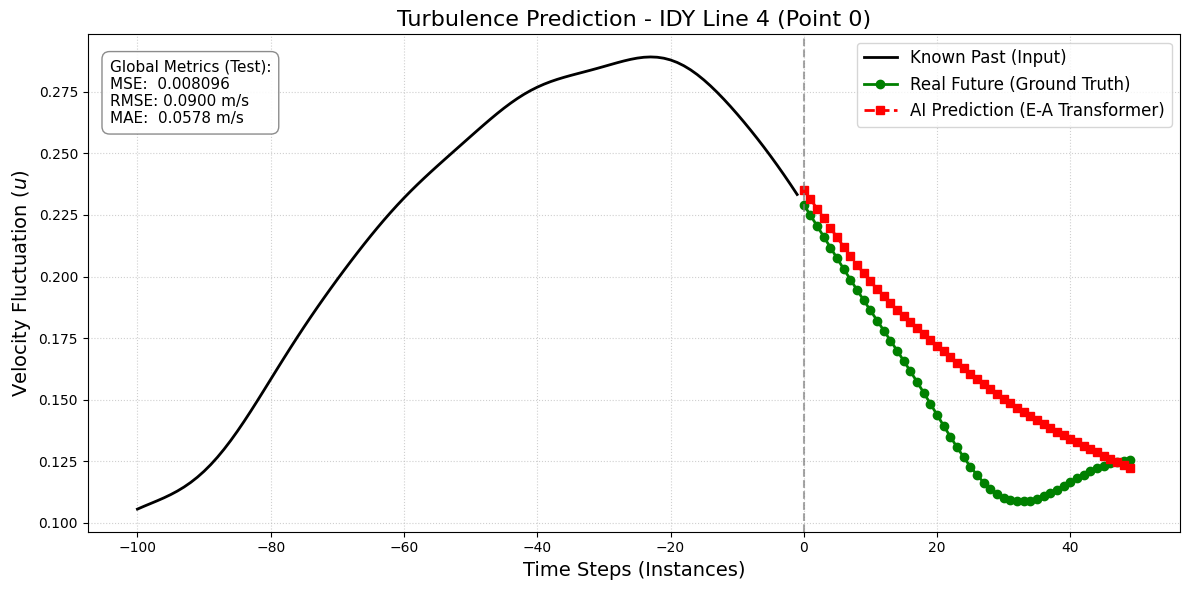

In [17]:
# ==========================================
# FASE DE INFERENCIA: PREDICCIÓN DE TURBULENCIA (VERSIÓN BLINDADA)
# ==========================================
import torch
import h5py
import numpy as np
import time
import matplotlib.pyplot as plt

# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 4  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 64  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len = ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

lr=0.001   # Tasa de aprendizaje para el optimizador



modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads)

# --- ⚙️ PARÁMETROS A MODIFICAR ⚙️ ---
ruta_modelo_campeon = ruta_carpeta_guardar + '/mejor_modelo_ia_transformer_eas.pt' 
ruta_stats = 'norm_stats_tf_3.pt'
linea_idy_test = 4  # ¡LA NUEVA LÍNEA!

# ==========================================
# 1. CARGAR EL MODELO Y LAS ESTADÍSTICAS
# ==========================================
print("2. Cargando estadísticas y modelo...")
stats = torch.load(ruta_stats, weights_only=False)
media_X = stats['media']
std_X = stats['std']

checkpoint_completo = torch.load(ruta_modelo_campeon, weights_only=False)
modelo.load_state_dict(checkpoint_completo['model_state_dict'])
modelo.to(device)
modelo.eval() # 🔴 MODO EXAMEN: APAGAR ENTRENAMIENTO

# ==========================================
# 2. PREPARAR LOS DATOS DE LA NUEVA LÍNEA
# ==========================================
print(f"3. Extrayendo la nueva línea de fluido (idy={linea_idy_test}) del disco...")
inicio = time.time()
with h5py.File(ruta_maestra, 'r') as f:
    matriz_base = f['data_analisis']['u_fluc'][:, linea_idy_test, :] 
    chunk_size = 5050
    num_chunks = len(matriz_base) // chunk_size 
    matriz_recortada = matriz_base[:num_chunks * chunk_size, :]
    
    trozos = []
    for i in range(num_chunks):
        trozos.append(matriz_recortada[i*chunk_size:(i+1)*chunk_size, :])
    matriz_final_test = np.hstack(trozos) 
print(f"   -> Datos extraídos en {time.time() - inicio:.2f} segundos.")

X_test_raw = matriz_final_test[5000-seq_len:5000, :] 
y_test_real = matriz_final_test[5000:5000+pred_len, :]  

X_test_norm = (X_test_raw - media_X) / std_X
X_tensor = torch.tensor(X_test_norm.T, dtype=torch.float32).unsqueeze(-1).to(device)

# ==========================================
# 3. LA PREDICCIÓN (CON PROTECCIÓN DE GPU)
# ==========================================
print("4. Pasando los datos por la Red Neuronal (Por lotes de 500)...")
inicio = time.time()
tamano_lote = 500  
predicciones = []

with torch.no_grad(): 
    for i in range(0, X_tensor.shape[0], tamano_lote):
        print(i)
        X_batch = X_tensor[i : i + tamano_lote]
        y_batch = modelo(X_batch)
        predicciones.append(y_batch)

y_pred_norm = torch.cat(predicciones, dim=0) 
print(f"   -> Predicción IA completada en {time.time() - inicio:.2f} segundos.")

# --- 🧹 LIMPIEZA DE MEMORIA VITAL ---
del X_tensor
del predicciones
torch.cuda.empty_cache()

# ==========================================
# 4. DESNORMALIZAR Y PREPARAR GRÁFICA
# ==========================================
print("5. Desnormalizando y dibujando resultados...")
y_pred_numpy = y_pred_norm.squeeze(-1).cpu().numpy()
y_pred_real = (y_pred_numpy * std_X) + media_X
y_pred_real = y_pred_real.T 

mse_test = np.mean((y_test_real - y_pred_real)**2)
rmse_test = np.sqrt(mse_test)
mae_test = np.mean(np.abs(y_test_real - y_pred_real))

punto_espacial = 0 

plt.figure(figsize=(12, 6))
pasado_reciente = X_test_raw[-100:, punto_espacial]
tiempo_pasado = range(-100, 0)
plt.plot(tiempo_pasado, pasado_reciente, 'k-', label='Known Past (Input)', linewidth=2)

tiempo_futuro = range(0, 50)
plt.plot(tiempo_futuro, y_test_real[:, punto_espacial], 'g-o', label='Real Future (Ground Truth)', linewidth=2)
plt.plot(tiempo_futuro, y_pred_real[:, punto_espacial], 'r--s', label='AI Prediction (E-A Transformer)', linewidth=2)

texto_metricas = (
    f"Global Metrics (Test):\n"
    f"MSE:  {mse_test:.6f}\n"
    f"RMSE: {rmse_test:.4f} m/s\n"
    f"MAE:  {mae_test:.4f} m/s"
)

plt.gca().text(0.02, 0.95, texto_metricas, 
               transform=plt.gca().transAxes, 
               fontsize=11, 
               verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title(f'Turbulence Prediction - IDY Line {linea_idy_test} (Point {punto_espacial})', fontsize=16)
plt.xlabel('Time Steps (Instances)', fontsize=14)
plt.ylabel('Velocity Fluctuation ($u$)', fontsize=14)
plt.legend(loc='upper right', fontsize=12) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

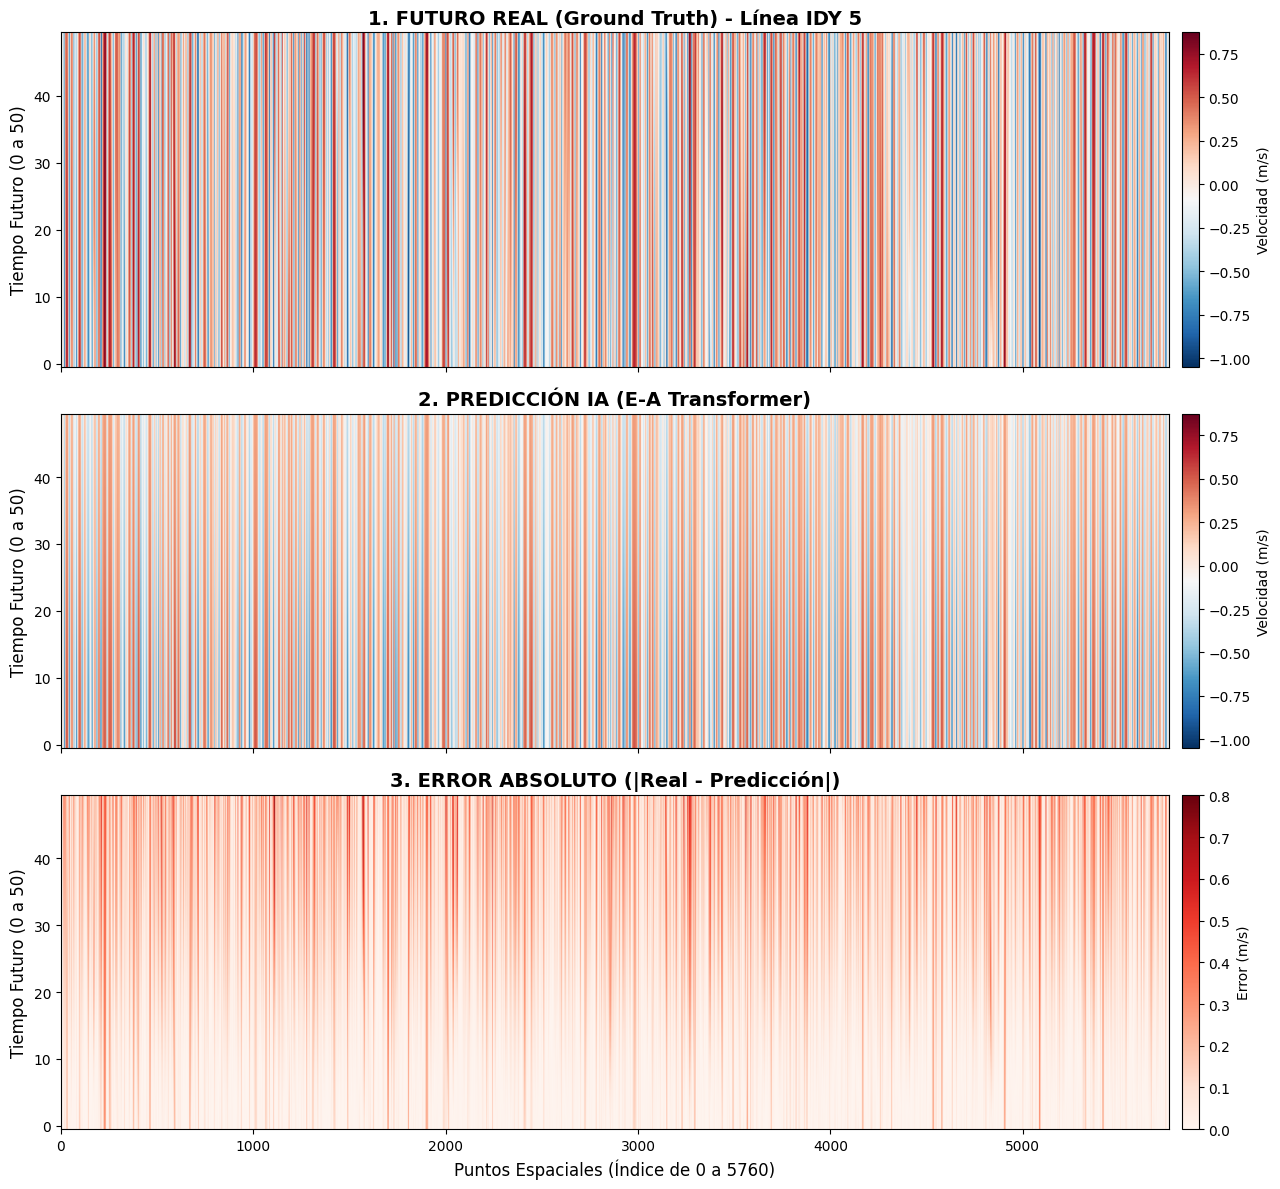

In [17]:
# ==========================================
# VISUALIZACIÓN CFD: MAPA DE CALOR ESPACIO-TEMPORAL
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Creamos una figura grande con 3 paneles apilados
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)

# 2. Fijamos los límites de color para que los 3 gráficos usen la misma escala
# Usamos el máximo y mínimo de la realidad para comparar justamente
vmin_val = np.min(y_test_real)
vmax_val = np.max(y_test_real)

# --- PANEL 1: FUTURO REAL (Lo que hizo el fluido de verdad) ---
im1 = ax1.imshow(y_test_real, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=vmin_val, vmax=vmax_val)
ax1.set_title(f"1. FUTURO REAL (Ground Truth) - Línea IDY {linea_idy_test}", fontsize=14, fontweight='bold')
ax1.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im1, ax=ax1, pad=0.01, label="Velocidad (m/s)")

# --- PANEL 2: PREDICCIÓN IA (Lo que cree tu modelo LSTM) ---
im2 = ax2.imshow(y_pred_real, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=vmin_val, vmax=vmax_val)
ax2.set_title("2. PREDICCIÓN IA (E-A Transformer)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im2, ax=ax2, pad=0.01, label="Velocidad (m/s)")

# --- PANEL 3: ERROR ABSOLUTO (Dónde falla el modelo) ---
error_absoluto = np.abs(y_test_real - y_pred_real)
im3 = ax3.imshow(error_absoluto, aspect='auto', cmap='Reds', origin='lower')
ax3.set_title("3. ERROR ABSOLUTO (|Real - Predicción|)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Puntos Espaciales (Índice de 0 a 5760)", fontsize=12)
ax3.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im3, ax=ax3, pad=0.01, label="Error (m/s)")

# Ajustamos el layout y mostramos
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🔮 PREDICCIÓN EXTREMA LSTM (ASOMÁNDOSE AL FUTURO DESCONOCIDO)
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- ⚙️ PARÁMETROS ---
instante_objetivo = 5010  # El momento exacto donde empieza la predicción
punto_espacial = 0 
seq_len = 5000            # 🚨 Adaptado a tu LSTM: Necesita 5000 pasos exactos de historia
pred_len = 50             # 🚨 Adaptado a tu LSTM: Escupe 50 pasos
# ---------------------

print(f"Prediciendo {pred_len} pasos a partir del instante {instante_objetivo}...")

# 1. Cogemos la historia exacta que la LSTM necesita (5000 pasos antes del 5010)
# Esto cogerá desde el instante 10 hasta el 5010
pasado_raw = matriz_final_test[instante_objetivo - seq_len : instante_objetivo, punto_espacial]

# 2. Cogemos LA REALIDAD QUE QUEDE (Limitado por el fin físico de la matriz en 5050)
limite_real = min(instante_objetivo + pred_len, matriz_final_test.shape[0])
futuro_real_raw = matriz_final_test[instante_objetivo : limite_real, punto_espacial]
pasos_reales_disponibles = len(futuro_real_raw)

# 3. Preparamos el tensor exactamente como lo espera tu LSTM
pasado_norm = (pasado_raw - media_X) / std_X

# A la LSTM le pasábamos shape (Batch, 5000). Usamos unsqueeze(0) para añadir el Batch=1.
x_tensor = torch.tensor(pasado_norm, dtype=torch.float32).unsqueeze(0).to(device)

# 4. La IA hace su trabajo completo (Predecir 50 pasos, sin recortar nada)
modelo.eval()
with torch.no_grad():
    prediccion_norm = modelo(x_tensor)

prediccion_numpy = prediccion_norm.cpu().numpy().squeeze() 
prediccion_real = (prediccion_numpy * std_X) + media_X
# ¡NO RECORTAMOS NADA! Nos quedamos con los 50 pasos de la LSTM íntegros.

# ==========================================
# 📊 DIBUJAMOS LA COMPARATIVA (Ejes independientes)
# ==========================================
plt.figure(figsize=(12, 6))

# Ejes de tiempo separados
tiempo_pasado = range(-seq_len, 0)
tiempo_futuro_ia = range(0, pred_len)                   # Siempre 50 pasos
tiempo_futuro_real = range(0, pasos_reales_disponibles) # Lo que quede (40 pasos si empiezas en 5010)

# Dibujamos el pasado (Solo mostramos los últimos 150 pasos para que no se vea una línea comprimida infinita)
plt.plot(tiempo_pasado[-150:], pasado_raw[-150:], 'k-', label=f'Pasado conocido (Zoom últimos 150)', linewidth=2)

# Dibujamos la realidad (se cortará antes de tiempo si choca con el final del archivo)
if pasos_reales_disponibles > 0:
    plt.plot(tiempo_futuro_real, futuro_real_raw, 'g-o', label=f'Realidad conocida ({pasos_reales_disponibles} pasos)', linewidth=2)

# Dibujamos la predicción completa de la IA (seguirá sola hacia el futuro)
plt.plot(tiempo_futuro_ia, prediccion_real, 'r--s', label=f'AI Prediction ({pred_len} pasos)', linewidth=2)

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title(f'LSTM: Predicción desde el instante {instante_objetivo}', fontsize=16)
plt.xlabel('Time Steps (Instances)', fontsize=14)
plt.ylabel('Velocity Fluctuation ($u$)', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Prediciendo 50 pasos a partir del instante 5010...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x5000 and 1x64)